# 🧠 Mental Health Intelligence Platform

## Phase 4 — Exploratory Data Analysis

### Overview

Understanding the demographic composition of survey respondents provides essential context for interpreting mental health trends throughout the remainder of this project.

This notebook explores the characteristics of individuals who participated in the OSMI Mental Health Survey across multiple years.

---

### Objectives

The objectives of this notebook are to:

- Analyze respondent age distribution
- Explore gender diversity
- Examine geographical distribution
- Investigate racial demographics
- Understand employment characteristics
- Explore company size representation


## Import Required Libraries

In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)

## Load Harmonized Dataset

In [15]:
df = pd.read_csv("../../data/processed/harmonized_osmi_data.csv")

print(df.shape)

df.head()

(3082, 70)


,source_file,survey_year,self_employed,no_employees,tech_company,primary_role_tech,benefits,know_options,formal_discussion,resources,anonymity,leave_ease,comfort_physical_mental,comfort_supervisor,discussed_with_employer,comfort_coworkers,discussed_with_coworkers,coworker_discussed_with_you,employer_importance_physical,employer_importance_mental,coverage_mental_health,know_resources,reveal_to_clients,reveal_to_coworkers,productivity_affected,productivity_percent_affected,have_prev_employers,prev_tech_company,prev_benefits,prev_know_options,prev_formal_discussion,prev_resources,prev_anonymity,prev_comfort_physical_mental,prev_comfort_supervisor,prev_discussed_with_employer,prev_comfort_coworkers,prev_discussed_with_coworkers,prev_employer_importance_physical,prev_employer_importance_mental,currently_disordered,diagnosed_disorder,past_disorder,sought_treatment,family_history,interference_when_treated,interference_when_not_treated,observations_less_likely_reveal,share_with_friends_family,bring_up_physical_interview,bring_up_mental_interview,bring_up_mental_why,openly_identified,identified_affected_career,identified_affected_how,team_reaction_if_knew,observed_unsupportive_response,unsupportive_response_desc,observed_supportive_response,industry_support_rating,improvement_suggestions,additional_comments,willing_to_interview,age,gender,country_live,state_live,race,country_work,state_work
0,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,Yes,Don't Know,No,Yes,Yes,Somewhat easy,Yes,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Often,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN
1,2014,2014,NaN,More than 1000,No,NaN,Don't Know,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,No,Maybe,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
2,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,No,No,No,No,Don't Know,Somewhat difficult,No,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
3,2014,2014,NaN,26-100,Yes,NaN,No,Yes,No,No,No,Somewhat difficult,No,No,Yes,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Often,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
4,2014,2014,NaN,100-500,Yes,NaN,Yes,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Never,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN


## Gender Distribution

Understanding gender representation within the dataset is essential for evaluating whether mental health experiences differ across demographic groups.

The harmonization process standardized gender responses into a consistent set of categories.

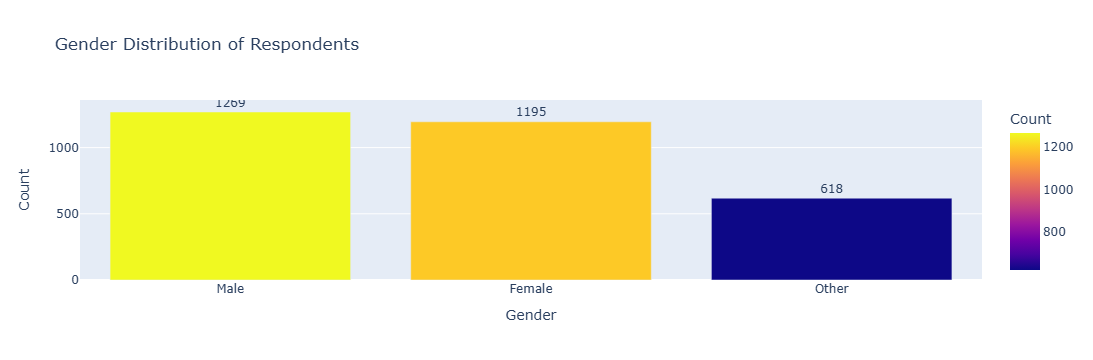

In [16]:
gender_counts = (
    df["gender"]
      .value_counts(dropna=False)
      .reset_index()
)

gender_counts.columns = ["Gender", "Count"]

fig = px.bar(
    gender_counts,
    x="Gender",
    y="Count",
    color="Count",
    text="Count",
    title="Gender Distribution of Respondents"
)

fig.update_traces(textposition="outside")

fig.show()

## Respondent Distribution by Country

The OSMI survey attracted participants from multiple countries.

Understanding geographical representation provides context for cultural and workplace differences observed later in the analysis.

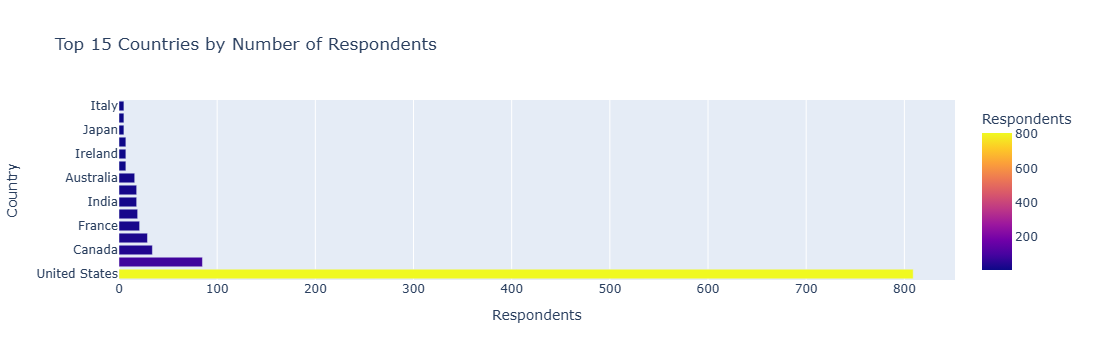

In [18]:
country = (
    df["country_live"]
      .value_counts()
      .head(15)
      .reset_index()
)

country.columns = ["Country", "Respondents"]

fig = px.bar(
    country,
    x="Respondents",
    y="Country",
    orientation="h",
    color="Respondents",
    title="Top 15 Countries by Number of Respondents"
)

fig.show()

## Global Distribution of Respondents

Visualizing respondent locations on a world map provides an intuitive understanding of the geographical coverage of the survey.

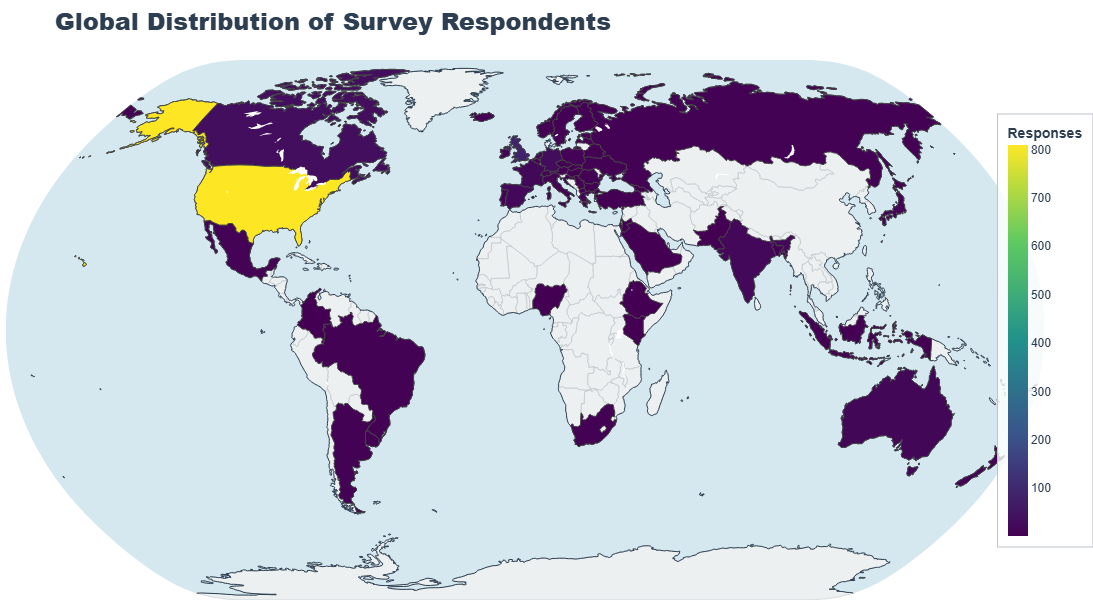

In [25]:
country_map = (
    df.groupby("country_live")
      .size()
      .reset_index(name="Responses")
)

fig = px.choropleth(
    country_map,
    locations="country_live",
    locationmode="country names",
    color="Responses",
    hover_name="country_live",
    hover_data={"Responses": True, "country_live": False},
    color_continuous_scale=[
        [0, "#440154"], [0.25, "#3b528b"], [0.5, "#21918c"], 
        [0.75, "#5ec962"], [1.0, "#fde725"]
    ],
    title="Global Distribution of Survey Respondents",
    labels={"Responses": "Number of Respondents", "country_live": "Country"}
)

fig.update_layout(
    title_font=dict(size=24, color="#2c3e50", family="Arial Black"),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="#2c3e50",
        showland=True,
        landcolor="#ecf0f1",
        showocean=True,
        oceancolor="#d5e8f0",
        showcountries=True,
        countrycolor="#bdc3c7",
        countrywidth=0.5,
        projection_type="natural earth"
    ),
    coloraxis_colorbar=dict(
        title="<b>Responses</b>",
        title_font=dict(size=14, color="#2c3e50"),
        tickfont=dict(size=12, color="#2c3e50"),
        thickness=20,
        len=0.8,
        x=0.95,
        y=0.5,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="#bdc3c7",
        borderwidth=1
    ),
    height=600,
    width=1000,
    margin=dict(l=0, r=0, t=60, b=0),
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial, sans-serif", color="#2c3e50")
)

total_responses = country_map["Responses"].sum()
fig.add_annotation(
    x=0.02,
    y=-0.08,
    xref="paper",
    yref="paper",
    text=f"Total Respondents: {total_responses:,}",
    showarrow=False,
    font=dict(size=14, color="#7f8c8d"),
    bgcolor="rgba(255,255,255,0.8)",
    bordercolor="#bdc3c7",
    borderwidth=1,
    borderpad=5
)

fig.show()

## Company Size Distribution

Company size influences workplace culture, organizational policies, and access to employee support programs.

Analyzing company size provides valuable context for later workplace analyses.

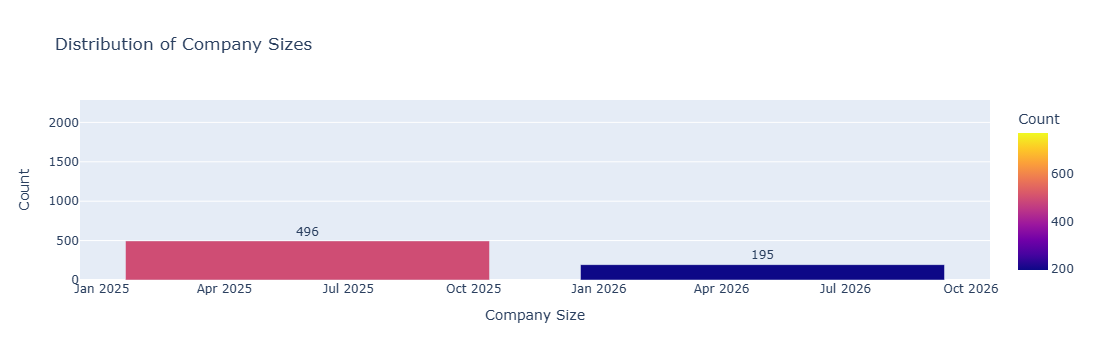

In [27]:
company = (
    df["no_employees"]
      .value_counts()
      .reset_index()
)

company.columns = ["Company Size", "Count"]

fig = px.bar(
    company,
    x="Company Size",
    y="Count",
    color="Count",
    text="Count",
    title="Distribution of Company Sizes"
)

fig.update_traces(textposition="outside")

fig.show()